In [1]:
"""
Multi-Layer Perceptron (Neural Network) for Kp Prediction
Undergraduate-level pipeline
"""


'\nMulti-Layer Perceptron (Neural Network) for Kp Prediction\nUndergraduate-level pipeline\n'

In [2]:
# ─────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
TRAIN_PATH = "data/train.csv"
TEST_PATH  = "data/test.csv"
TARGET = "Kp_3h_ahead"
MODEL_DIR = "models/neural_network"

# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Select numeric features
exclude_cols = [TARGET, "Timestamp", "Datetime"]
feature_cols = [c for c in train_df.columns if c not in exclude_cols and train_df[c].dtype != "object"]

X_train = train_df[feature_cols]
y_train = train_df[TARGET]

X_test = test_df[feature_cols]
y_test = test_df[TARGET]

print("Number of features:", len(feature_cols))


Train shape: (7144, 68)
Test shape : (1786, 68)
Number of features: 65


In [4]:
# ─────────────────────────────────────────
# HANDLE MISSING VALUES (REQUIRED FOR NN)
# ─────────────────────────────────────────
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# ─────────────────────────────────────────
# SCALE FEATURES (IMPORTANT FOR NN)
# ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ─────────────────────────────────────────
# TRAIN NEURAL NETWORK
# ─────────────────────────────────────────
print("\nTraining Neural Network...")

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)

mlp.fit(X_train, y_train)
print("Training complete!")



Training Neural Network...
Training complete!


/Users/dhrithikiran/Downloads/Auroral_Prediction_Project/path/to/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [5]:
# ─────────────────────────────────────────
# PREDICTIONS
# ─────────────────────────────────────────
y_pred_train = mlp.predict(X_train)
y_pred_test  = mlp.predict(X_test)

# ─────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────
def evaluate(y_true, y_pred, name="Test"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n==== {name} Results ====")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return mae, rmse, r2

train_metrics = evaluate(y_train, y_pred_train, "Train")
test_metrics  = evaluate(y_test, y_pred_test, "Test")



==== Train Results ====
MAE  : 0.2264
RMSE : 0.2952
R²   : 0.9511

==== Test Results ====
MAE  : 0.9818
RMSE : 1.3577
R²   : 0.1048


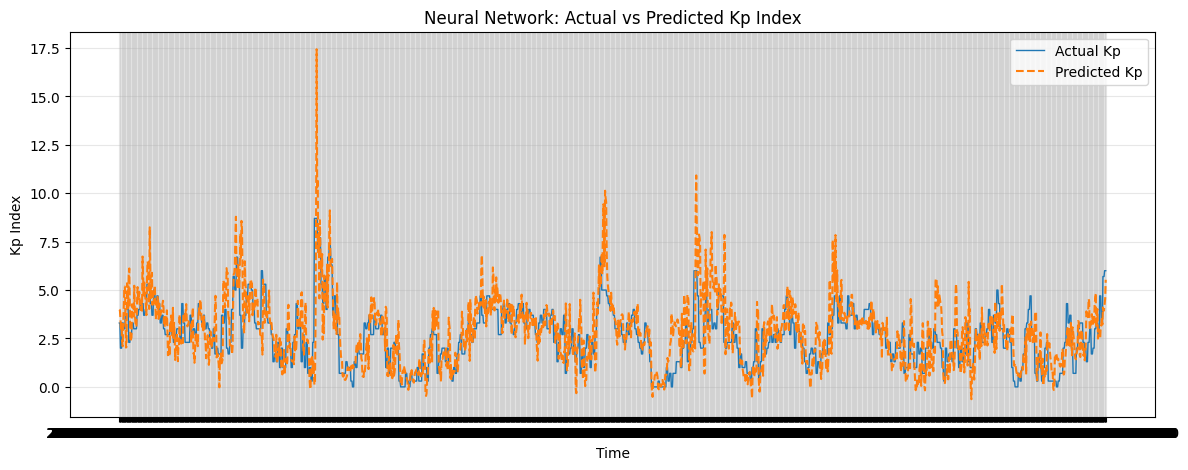

In [6]:
# ─────────────────────────────────────────────────────────
# STEP 7 — PLOT RESULTS
# ─────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

# Plot actual vs predicted Kp over time
plt.figure(figsize=(14,5))
plt.plot(test_df["Timestamp"], y_test, label="Actual Kp", linewidth=1)
plt.plot(test_df["Timestamp"], y_pred_test, label="Predicted Kp", linestyle="--")

plt.title("Neural Network: Actual vs Predicted Kp Index")
plt.xlabel("Time")
plt.ylabel("Kp Index")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [7]:
# ─────────────────────────────────────────
# SAVE MODEL & RESULTS
# ─────────────────────────────────────────
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model & scaler
joblib.dump(mlp, f"{MODEL_DIR}/mlp_model.pkl")
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
print("Model and scaler saved!")

# Save predictions
pred_df = pd.DataFrame({
    "Timestamp": test_df["Timestamp"],
    "Actual_Kp": y_test,
    "Predicted_Kp": y_pred_test
})
pred_df.to_csv(f"{MODEL_DIR}/test_predictions.csv", index=False)

# Save metrics
metrics_df = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MAE": [train_metrics[0], test_metrics[0]],
    "RMSE": [train_metrics[1], test_metrics[1]],
    "R2": [train_metrics[2], test_metrics[2]]
})
metrics_df.to_csv(f"{MODEL_DIR}/metrics.csv", index=False)

print("Metrics saved!")
print("\nNeural Network Pipeline Finished Successfully.")


Model and scaler saved!
Metrics saved!

Neural Network Pipeline Finished Successfully.
